# Example: Autoencoder on MNIST
In this example, we train a nonlinear autoencoder on MNIST handwritten digit images. The autoencoder compresses each $28\times 28 = 784$-dimensional image into a 2-dimensional bottleneck code and reconstructs the image from that code. After training, we visualize the learned 2D embeddings to see how the autoencoder organizes different digit classes, and compare the reconstruction quality and embedding structure to PCA.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * __Train an autoencoder:__ Build and train a nonlinear autoencoder with a 2D bottleneck on MNIST using mean squared error reconstruction loss. Monitor the loss curve to verify convergence.
> * __Visualize bottleneck embeddings:__ Extract the 2D bottleneck codes for each digit and plot them colored by class label. Compare the structure of the autoencoder embedding to a 2D PCA projection of the same data.
> * __Evaluate reconstruction quality:__ Compare original and reconstructed images side-by-side for both the autoencoder and PCA. Assess how well each method preserves digit features at the same bottleneck dimension.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes local source files in `src/`. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Data
We use the MNIST handwritten digit dataset, the same dataset used in the L8c feedforward network example. Each image is a $28\times 28$ grayscale image flattened into a 784-dimensional vector with pixel values normalized to $[0,1]$. Let's load the training images and store them in the `training_data` variable.

In [2]:
number_of_examples, digits_image_dictionary = let
    
    # initialize -
    number_of_examples = 1000; # how many training examples of *each* digit to include (must be even)
    digits_image_dictionary = MyMNISTHandwrittenDigitImageDataset(); # this loads *all* the data into memory, which is not ideal, but it is simple for demonstration purposes. 

    (number_of_examples, digits_image_dictionary)
end;

In [3]:
digits_image_dictionary

Dict{Int64, Array{Gray{FixedPointNumbers.N0f8}, 3}} with 10 entries:
  0 => [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … …
  4 => [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … …
  5 => [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … …
  6 => [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … …
  2 => [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … …
  7 => [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … …
  9 => [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … …
  8 => [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.004 0.00…
  3 => [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … …
  1 => [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … …

In [4]:
digits_image_dictionary[1] |> data -> size(data,3)

1000

Next, we flatten the images into vectors and normalize to $[0,1]$. We store the training data in `X_train::Matrix{Float32}` (each column is one image) and the corresponding labels in `y_train::Vector{Int}`.

In [5]:
X_train, y_train = let

    # initialize storage for flattened images and labels -
    images = Vector{Vector{Float32}}();
    labels = Vector{Int}();

    # iterate over each digit class (0-9) -
    for digit in 0:9
        data = digits_image_dictionary[digit]; # 28 x 28 x n_examples array
        n = size(data, 3);
        for i in 1:n
            img_vec = Float32.(vec(data[:, :, i])); # flatten 28x28 to 784-vector
            push!(images, img_vec);
            push!(labels, digit);
        end
    end

    # stack into matrix (784 x N), each column is one image -
    X = hcat(images...);
    (X, labels)
end;
println("Training data size: $(size(X_train)), labels: $(length(y_train))")

Training data size: (784, 10000), labels: 10000


___

## Task 1: Build and Train the Autoencoder
We build a nonlinear autoencoder with a symmetric architecture: the encoder compresses the 784-dimensional input down to a 2-dimensional bottleneck, and the decoder mirrors the encoder to reconstruct the input.

> __Architecture__
>
> The encoder has layers $784 \to 128 \to 2$ with ReLU activations on the hidden layer and linear activation on the bottleneck. The decoder has layers $2 \to 128 \to 784$ with ReLU on the hidden layer and sigmoid on the output (to produce pixel values in $[0,1]$). The model is trained by minimizing mean squared error between the input and reconstruction.

We define the encoder and decoder using [`Flux.jl`](https://fluxml.ai/Flux.jl/stable/). The [`Chain`](https://fluxml.ai/Flux.jl/stable/models/layers/#Flux.Chain) function composes layers sequentially, and [`Dense`](https://fluxml.ai/Flux.jl/stable/models/layers/#Flux.Dense) creates a fully connected layer.

In [6]:
encoder, decoder, autoencoder = let

    # encoder: 784 → 128 (relu) → 2 (linear bottleneck) -
    encoder = Chain(
        Dense(784, 128, relu),
        Dense(128, 2)
    );

    # decoder: 2 → 128 (relu) → 784 (sigmoid to keep pixels in [0,1]) -
    decoder = Chain(
        Dense(2, 128, relu),
        Dense(128, 784, sigmoid)
    );

    # full autoencoder: encoder followed by decoder -
    autoencoder = Chain(encoder, decoder);
    println("Autoencoder parameters: $(sum(length, Flux.params(autoencoder)))");

    (encoder, decoder, autoencoder)
end;

┌ Warning: `Flux.params(m...)` is deprecated. Use `Flux.trainable(model)` for parameter collection,
│ and the explicit `gradient(m -> loss(m, x, y), model)` for gradient computation.
└ @ Flux /Users/jdv27/.julia/packages/Flux/DZYiO/src/deprecations.jl:93


Autoencoder parameters: 202258


Now we train the autoencoder using the [`Adam`](https://fluxml.ai/Flux.jl/stable/training/optimisers/#Flux.Optimise.Adam) optimizer. The loss function is the mean squared error ([`Flux.mse`](https://fluxml.ai/Flux.jl/stable/models/losses/#Flux.Losses.mse)) between the input and the reconstruction. We use [`Flux.withgradient`](https://fluxml.ai/Flux.jl/stable/training/training/#Flux.withgradient-Tuple{Any,%20Vararg{Any}}) to compute the loss and gradients in a single pass. We store the per-epoch average loss in `loss_history`.

> For a detailed treatment of the Adam algorithm, including the full update rule, bias correction derivation, and hyperparameter guidelines, see the [Advanced: The Adam Optimizer](CHEME-5820-L10c-Advanced-Adam-Spring-2026.ipynb) notebook.

In [7]:
loss_history = let

    # hyperparameters -
    η = 1e-3;           # learning rate for Adam
    num_epochs = 50;    # number of passes through the training data
    batch_size = 128;   # number of images per mini-batch
    N = size(X_train, 2);

    # initialize optimizer state -
    opt_state = Flux.setup(Adam(η), autoencoder);
    history = Vector{Float64}();

    # training loop: iterate over epochs -
    for epoch in 1:num_epochs
        epoch_loss = 0.0;
        indices = shuffle(1:N); # random permutation for mini-batching
        num_batches = 0;

        # iterate over mini-batches -
        for start in 1:batch_size:N
            stop = min(start + batch_size - 1, N);
            batch = X_train[:, indices[start:stop]];

            # forward pass: compute reconstruction and MSE loss -
            loss_val, grads = Flux.withgradient(autoencoder) do model
                x_hat = model(batch);
                Flux.mse(x_hat, batch);
            end

            # backward pass: update parameters -
            Flux.update!(opt_state, autoencoder, grads[1]);
            epoch_loss += loss_val;
            num_batches += 1;
        end

        # record average loss for this epoch -
        push!(history, epoch_loss / num_batches);
    end

    history
end;
println("Training complete. Final loss: $(round(loss_history[end], digits=6))")

Training complete. Final loss: 0.043017


Let's plot the training loss to verify that the model converges.

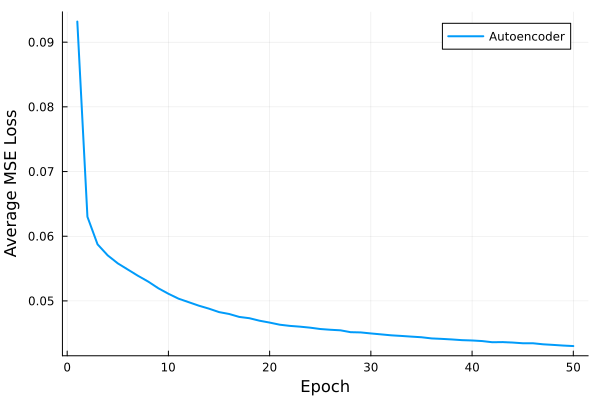

In [8]:
let
    plot(loss_history, xlabel="Epoch", ylabel="Average MSE Loss", label="Autoencoder", lw=2)
end

___

## Task 2: Visualize Bottleneck Embeddings
We extract the 2D bottleneck codes by passing all training images through the encoder. Each image maps to a point in $\mathbb{R}^{2}$, and we color the points by digit class to see how the autoencoder organizes the data.

> __Bottleneck as embedding__
>
> The encoder maps each 784-dimensional image to a 2D code $\mathbf{z} = f_{\mathrm{enc}}(\mathbf{x})$. If the autoencoder has learned useful structure, images of the same digit should cluster together in the 2D space, and different digits should occupy distinct regions.

We store the 2D codes in `Z::Matrix{Float32}` of shape $2 \times N$.

In [9]:
Z = let
    
    # pass all training images through the encoder to get 2D codes -
    Z = encoder(X_train);
    println("Bottleneck codes size: $(size(Z))");
    Z
end;

Bottleneck codes size: (2, 10000)


Let's scatter plot the 2D codes colored by digit label using [`scatter!`](https://docs.juliaplots.org/stable/api/#Plots.scatter!-Tuple{})  from [`Plots.jl`](https://docs.juliaplots.org/stable/).

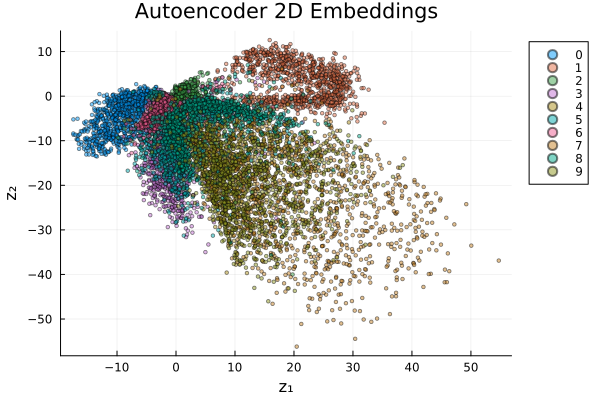

In [10]:
let
    p = plot(xlabel="z₁", ylabel="z₂", title="Autoencoder 2D Embeddings", legend=:outertopright)
    
    # plot each digit class as a separate series for color coding -
    for digit in 0:9
        idx = findall(y_train .== digit);
        scatter!(p, Z[1, idx], Z[2, idx], label="$digit", ms=2, alpha=0.5)
    end
    p
end

___

## Task 3: Compare to PCA
To understand what the nonlinear autoencoder gains over a linear method, we project the same data onto the first 2 principal components and compare the embeddings and reconstructions.

> __PCA baseline__
>
> PCA finds the 2D linear subspace that captures the most variance in the data. The autoencoder finds a 2D nonlinear manifold. By comparing the two, we can see whether the autoencoder captures structure that PCA misses.

We compute the PCA projection using the [`svd`](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.svd) function from [`LinearAlgebra`](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/) and store the 2D coordinates in `Z_pca`.

In [11]:
Z_pca, V_d, μ = let

    # center the data (PCA requires zero-mean columns) -
    X = Float64.(X_train);
    μ = mean(X, dims=2);
    X_centered = X .- μ;

    # compute the SVD of the centered data matrix -
    U, S, V = svd(X_centered');

    # project onto the top 2 right singular vectors (principal component directions) -
    V_d = V[:, 1:2];
    Z_pca = V_d' * X_centered;

    (Z_pca, V_d, μ)
end;
println("PCA projection size: $(size(Z_pca))")

PCA projection size: (2, 10000)


Let's plot the PCA 2D projection alongside the autoencoder embedding.

In [ ]:
let
    # autoencoder embedding -
    p1 = plot(xlabel="z₁", ylabel="z₂", title="Autoencoder", legend=false, left_margin=5Plots.mm, bottom_margin=5Plots.mm)
    
    # PCA embedding -
    p2 = plot(xlabel="PC₁", ylabel="PC₂", title="PCA", legend=false, left_margin=5Plots.mm, bottom_margin=5Plots.mm)

    # plot each digit class in both panels -
    for digit in 0:9
        idx = findall(y_train .== digit);
        scatter!(p1, Z[1, idx], Z[2, idx], label="$digit", ms=2, alpha=0.5)
        scatter!(p2, Z_pca[1, idx], Z_pca[2, idx], label="$digit", ms=2, alpha=0.5)
    end

    plot(p1, p2, layout=(1, 2), size=(1000, 450))
end

### Reconstruction Comparison
Let's compare reconstructions from both methods for a few sample digits.

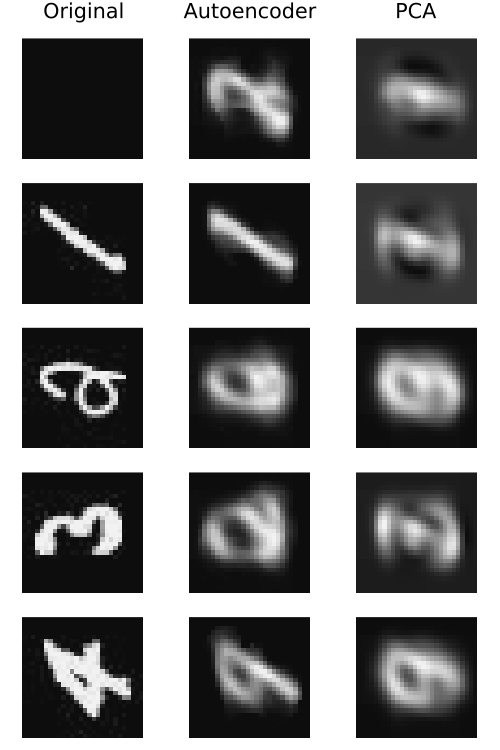

In [13]:
let
    sample_indices = [1, 1001, 2001, 3001, 4001]; # one example from digits 0-4
    n = length(sample_indices);

    plots = [];
    for (col, idx) in enumerate(sample_indices)
        
        # original image: reshape from 784-vector to 28x28 matrix -
        img_orig = reshape(X_train[:, idx], 28, 28)';

        # autoencoder reconstruction: pass through full model -
        img_ae = reshape(autoencoder(X_train[:, idx]), 28, 28)';

        # PCA reconstruction: project onto top 2 PCs and reconstruct -
        x_centered = Float64.(X_train[:, idx]) .- μ;
        img_pca = reshape(V_d * (V_d' * x_centered) .+ μ, 28, 28)';

        # build the grid: columns are Original | Autoencoder | PCA -
        push!(plots, heatmap(img_orig, color=:grays, axis=false, ticks=false,
            title=(col == 1 ? "Original" : ""), aspect_ratio=1, colorbar=false));
        push!(plots, heatmap(img_ae, color=:grays, axis=false, ticks=false,
            title=(col == 1 ? "Autoencoder" : ""), aspect_ratio=1, colorbar=false));
        push!(plots, heatmap(img_pca, color=:grays, axis=false, ticks=false,
            title=(col == 1 ? "PCA" : ""), aspect_ratio=1, colorbar=false));
    end

    plot(plots..., layout=(n, 3), size=(500, n * 150))
end

___

## Summary
In this example, we trained a nonlinear autoencoder on MNIST and compared its learned 2D embeddings and reconstructions to PCA.

> __Key Takeaways__:
>
> * __Autoencoders learn nonlinear embeddings:__ The 2D bottleneck codes show digit clusters with curved boundaries that a linear method cannot produce. The autoencoder organizes digits by visual similarity in the embedding space.
> * __PCA captures variance, autoencoders capture structure:__ PCA projects onto the directions of maximum variance, which may mix visually distinct digits. The autoencoder optimizes for reconstruction, which encourages separation of digits that look different.
> * __Reconstruction quality reflects embedding quality:__ At the same bottleneck dimension ($d = 2$), the autoencoder typically produces sharper reconstructions than PCA because the nonlinear encoder and decoder can represent more complex transformations.

These results illustrate how autoencoders extend the embedding concept from text (L9a-L10a) to image data, and how nonlinearity enables representations that linear methods cannot achieve.
___